# ✈️ Uçuş Bilet Fiyatı Analizi, Özellik Mühendisliği ve Hiperparametre Optimizasyonlu Makine Öğrenmesi Modeli

Bu Jupyter Notebook çalışmasında **`flight_cleaned.csv`** veri seti kullanılarak uçuş bilet fiyatları üzerinde:
1. **Keşifçi Veri Analizi (EDA) ve Temizlik**
2. **Kategorik Değişkenlerin Fiyat İle İlişkisi ve Gruplama**
3. **Tarih ve Zaman Alanlarından Özellik Mühendisliği (Feature Engineering)**
4. **Train / Test Veri Seti Ayrımı ve Ön İşleme (Preprocessing)**
5. **Çeşitli Regresyon Modelleri (Linear Regression, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM) İle Modelleme**
6. **Hiperparametre Optimizasyonu (Hyperparameter Tuning - RandomizedSearchCV)**
7. **Detaylı Hata ve Artık (Residual & Error Diagnosis) Analizi:** *Hatalar rastgele mi (random noise) yoksa sistematik bir desene mi sahip?*
8. **Model Karşılaştırması ve İş Çıkarımları**

gerçekleştirilmiştir.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Imports
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})
print("✅ Kütüphaneler başarıyla yüklendi.")


✅ Kütüphaneler başarıyla yüklendi.


## 1. 📂 Veri Yükleme ve İlk İnceleme

Veri seti yüklenerek boyut, veri tipleri, eksik değerler ve örnek satırlar incelenir.


In [2]:
# Veri setini yükle
df_raw = pd.read_csv('flight_cleaned.csv')

print(f"Veri Boyutu: {df_raw.shape[0]} satır, {df_raw.shape[1]} sütun")
print("\n=== Sütun Bilgileri ve Veri Tipleri ===")
print(df_raw.info())

print("\n=== Eksik Değer Değerlendirmesi ===")
print(df_raw.isnull().sum())

print("\n=== İlk 3 Satır ===")
df_raw.head(3)


Veri Boyutu: 6062 satır, 17 sütun

=== Sütun Bilgileri ve Veri Tipleri ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6062 entries, 0 to 6061
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        6062 non-null   int64 
 1   From              6062 non-null   object
 2   To                6062 non-null   object
 3   Booking_date      6062 non-null   object
 4   Journey_date      6062 non-null   object
 5   Airline           6062 non-null   object
 6   Code              6062 non-null   object
 7   Departure         6062 non-null   object
 8   Arrival           6062 non-null   object
 9   Duration          6062 non-null   object
 10  Stops             6062 non-null   object
 11  Price             6062 non-null   int64 
 12  Booking_Hour      6062 non-null   int64 
 13  Booking_DateTime  6062 non-null   object
 14  Booking_Slot      6062 non-null   object
 15  Lead_Time_Days    6062 non-null

,Unnamed: 0,From,To,Booking_date,Journey_date,Airline,Code,Departure,Arrival,Duration,Stops,Price,Booking_Hour,Booking_DateTime,Booking_Slot,Lead_Time_Days,Duration_mins
0,0,Delhi,Bangalore,23-06-2022,23-06-2022,Air India,AI-504,21:15,00:05\r\n+1D,2h 50m,non-stop,9420,6,23-06-2022 06:00,Morning,0,170
1,1,Delhi,Bangalore,23-06-2022,23-06-2022,IndiGo,6E-2131,21:30,00:15\r\n+1D,2h 45m,non-stop,9419,19,23-06-2022 19:00,Evening,0,165
2,2,Delhi,Bangalore,23-06-2022,23-06-2022,IndiGo,6E-6565,22:55,01:45\r\n+1D,2h 50m,non-stop,9419,14,23-06-2022 14:00,Afternoon,0,170


## 2. 🧹 Veri Temizleme ve Standartlaştırma (Data Cleaning)

* `Unnamed: 0` gereksiz indeks sütunu kaldırılır.
* `Airline` sütunundaki yazım hataları (`Indigo` -> `IndiGo`, `AirAsia` -> `Air Asia`) düzeltilir.
* `From` ve `To` şehir isimleri baş harfleri büyük olacak şekilde standartlaştırılır.
* `Stops` (Aktarma) metinleri sayısal değerlere dönüştürülür (`non-stop` -> 0, `1 stop` -> 1, `2 stops` -> 2).


In [3]:
df = df_raw.copy()

# 1. Gereksiz indeks sütununu kaldır
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# 2. Havayolu isimlerini standartlaştır
airline_fixes = {'Indigo': 'IndiGo', 'AirAsia': 'Air Asia'}
df['Airline'] = df['Airline'].replace(airline_fixes)

# 3. Şehir isimlerini standartlaştır
df['From'] = df['From'].str.title()
df['To'] = df['To'].str.title()
df['Route'] = df['From'] + " -> " + df['To']

# 4. Stops (Aktarma) alanını sayısala çevir
def parse_stops(val):
    s = str(val).lower()
    if 'non-stop' in s:
        return 0
    elif '1' in s:
        return 1
    elif '2' in s:
        return 2
    return 0

df['Stops_Num'] = df['Stops'].apply(parse_stops)

print("✅ Veri temizleme tamamlandı.")
print("Güncel Havayolu İsimleri:", df['Airline'].unique())
print("\nAktarma Sayısı Dağılımı:\n", df['Stops_Num'].value_counts())


✅ Veri temizleme tamamlandı.
Güncel Havayolu İsimleri: ['Air India' 'IndiGo' 'Vistara' 'GO FIRST' 'SpiceJet' 'Air Asia']

Aktarma Sayısı Dağılımı:
 Stops_Num
1    4292
0    1307
2     463
Name: count, dtype: int64


## 3. 📊 Kategorik Değişkenlerin Fiyat İle İlişkisi ve Gruplama

Fiyat (`Price`) hedef değişkeninin kategorik özelliklerle olan ilişkisi istatistiksel özetler ve grafiklerle incelenir.


In [4]:
# Havayollarına göre bilet fiyat istatistikleri
airline_price_stats = df.groupby('Airline')['Price'].agg(['count', 'min', 'mean', 'median', 'max', 'std']).round(2)
print("=== HAVAYOLU BAZLI FİYAT İSTATİSTİKLERİ (INR) ===")
display(airline_price_stats)

# Rotaya göre bilet fiyat istatistikleri
route_price_stats = df.groupby('Route')['Price'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)
print("\n=== ROTA BAZLI FİYAT İSTATİSTİKLERİ (INR) ===")
display(route_price_stats)


=== HAVAYOLU BAZLI FİYAT İSTATİSTİKLERİ (INR) ===


,count,min,mean,median,max,std
Airline,,,,,,
Air Asia,381,7789,11551.76,9678.0,35462,4492.48
Air India,458,7845,15165.79,15510.0,33153,3955.34
GO FIRST,691,8568,10961.35,9419.0,31214,3525.54
IndiGo,1756,7789,10140.13,9679.0,30552,2294.48
SpiceJet,223,7789,9828.08,9419.0,23558,2437.99
Vistara,2553,8566,15236.92,15295.0,47584,3999.22



=== ROTA BAZLI FİYAT İSTATİSTİKLERİ (INR) ===


,count,mean,median,min,max
Route,,,,,
Bangalore -> Delhi,776,13010.09,12094.0,9677,35462
Bangalore -> Kolkata,646,13468.99,12232.0,7789,47584
Delhi -> Bangalore,1074,13647.38,15295.0,9418,30957
Delhi -> Goa,588,12807.65,9734.0,9418,27690
Delhi -> Mumbai,939,12321.98,9451.0,7845,33153
Goa -> Delhi,564,13015.38,10997.0,9621,32092
Kolkata -> Bangalore,590,13144.77,12046.0,9028,34645
Mumbai -> Delhi,885,11488.84,8883.0,8462,35656


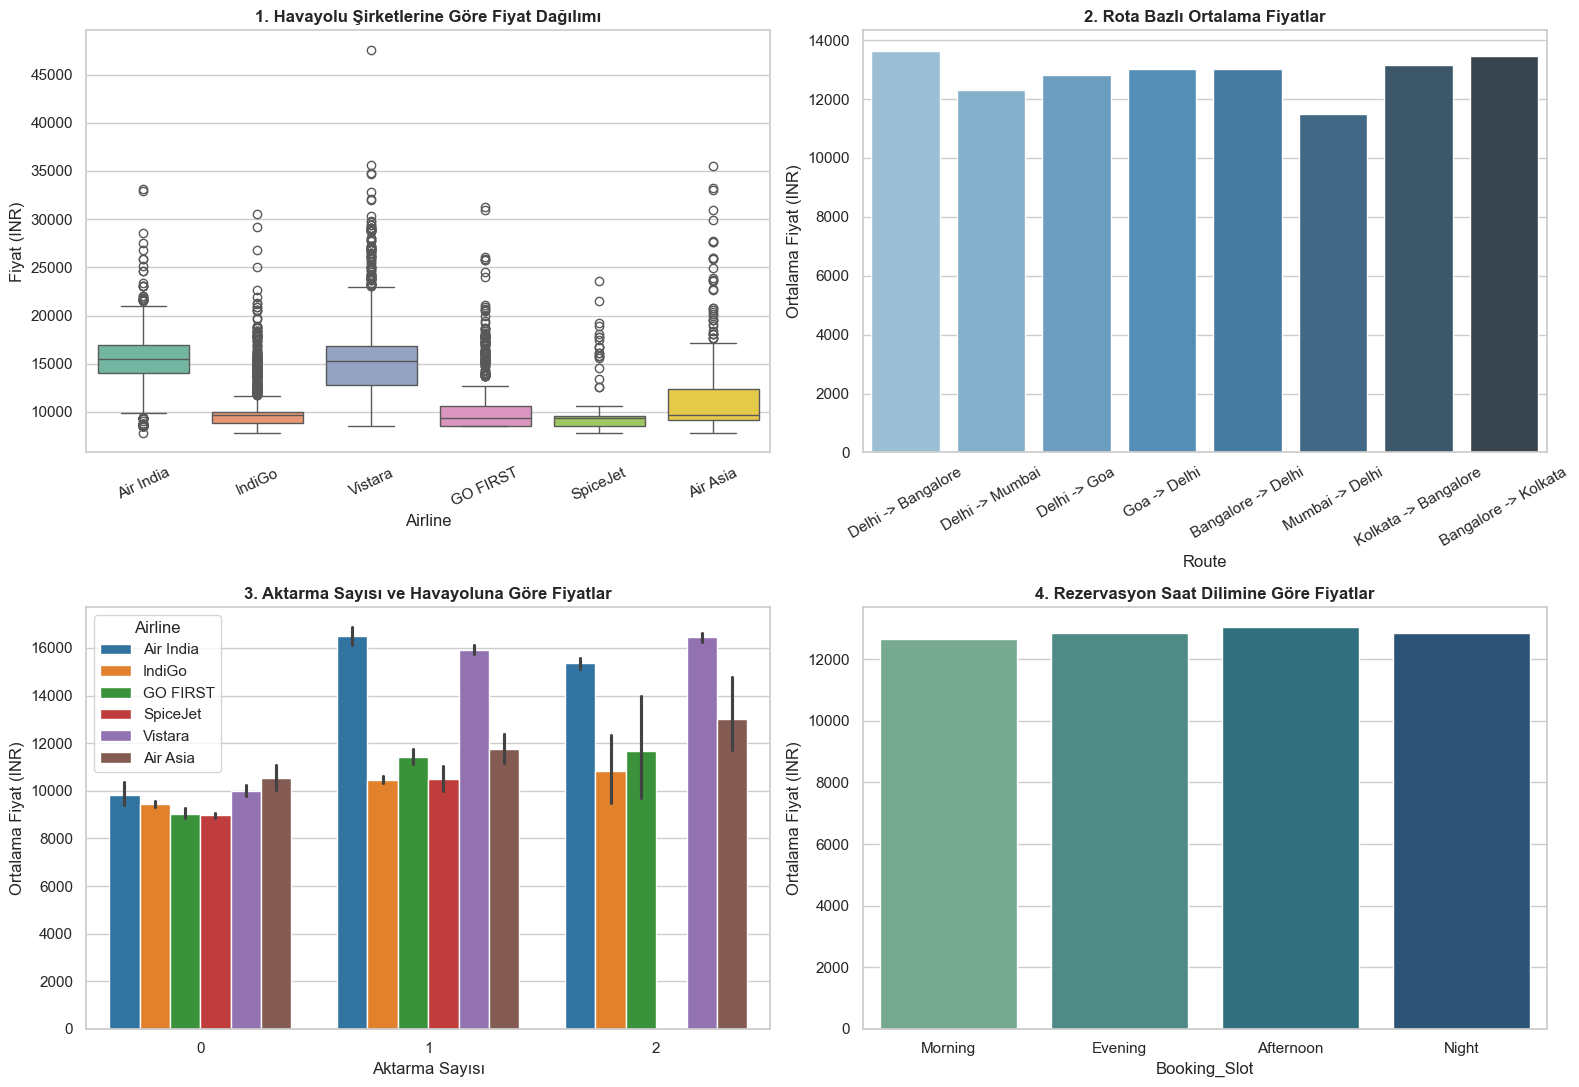

In [5]:
# Görselleştirmeler
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Plot 1: Airline vs Price Boxplot
sns.boxplot(data=df, x='Airline', y='Price', hue='Airline', ax=axes[0, 0], palette="Set2", legend=False)
axes[0, 0].set_title('1. Havayolu Şirketlerine Göre Fiyat Dağılımı', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=25)
axes[0, 0].set_ylabel('Fiyat (INR)')

# Plot 2: Route vs Price Barplot
sns.barplot(data=df, x='Route', y='Price', ax=axes[0, 1], palette="Blues_d", errorbar=None)
axes[0, 1].set_title('2. Rota Bazlı Ortalama Fiyatlar', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].set_ylabel('Ortalama Fiyat (INR)')

# Plot 3: Stops vs Price
sns.barplot(data=df, x='Stops_Num', y='Price', hue='Airline', ax=axes[1, 0], palette="tab10")
axes[1, 0].set_title('3. Aktarma Sayısı ve Havayoluna Göre Fiyatlar', fontweight='bold')
axes[1, 0].set_xlabel('Aktarma Sayısı')
axes[1, 0].set_ylabel('Ortalama Fiyat (INR)')

# Plot 4: Booking Slot vs Price
sns.barplot(data=df, x='Booking_Slot', y='Price', ax=axes[1, 1], palette="crest", errorbar=None)
axes[1, 1].set_title('4. Rezervasyon Saat Dilimine Göre Fiyatlar', fontweight='bold')
axes[1, 1].set_ylabel('Ortalama Fiyat (INR)')

plt.tight_layout()
plt.show()


## 4. 🛠️ Özellik Mühendisliği (Feature Engineering)

Model başarımını artırmak için ham tarih ve saat verilerinden yeni türetilmiş değişkenler oluşturulur:
1. **Tarih Özellikleri:** `Booking_date` ve `Journey_date` datetime'a çevrilerek `Journey_Day`, `Journey_Month`, `Journey_DayOfWeek` (Haftanın günü) ve `Journey_IsWeekend` (Hafta sonu mu?) türetilir.
2. **Kalkış / Varış Saat Özellikleri:** `Departure` ve `Arrival` saatlerinden `Dep_Hour`, `Dep_Minute`, `Arr_Hour`, `Arr_Minute` ve `Is_Next_Day` (ertesi gün varış) çıkarılır.
3. **Zaman Dilimleri:** Kalkış ve varış saatleri günün dilimlerine ayrılır (`Morning`, `Afternoon`, `Evening`, `Night`).
4. **Havayolu Segmenti:** Premium vs Bütçe dostu havayolu ayrımı (`Is_Premium_Airline`).


In [6]:
# 1. Tarih Dönüşümleri
df['Booking_date_dt'] = pd.to_datetime(df['Booking_date'], format='%d-%m-%Y')
df['Journey_date_dt'] = pd.to_datetime(df['Journey_date'], format='%d-%m-%Y')

df['Journey_Day'] = df['Journey_date_dt'].dt.day
df['Journey_Month'] = df['Journey_date_dt'].dt.month
df['Journey_DayOfWeek'] = df['Journey_date_dt'].dt.dayofweek
df['Journey_IsWeekend'] = df['Journey_DayOfWeek'].isin([5, 6]).astype(int)

# 2. Kalkış Saati Parse
df['Dep_Hour'] = pd.to_datetime(df['Departure'], format='%H:%M').dt.hour
df['Dep_Minute'] = pd.to_datetime(df['Departure'], format='%H:%M').dt.minute

# 3. Varış Saati ve Ertesi Gün Kontrolü Parse
def parse_arrival(arr_str):
    arr_str = str(arr_str).replace('\r', '').replace('\n', ' ')
    is_next_day = 1 if '+1D' in arr_str or '+2D' in arr_str else 0
    time_part = arr_str.split()[0]
    try:
        dt = pd.to_datetime(time_part, format='%H:%M')
        return dt.hour, dt.minute, is_next_day
    except:
        return 0, 0, is_next_day

arr_parsed = df['Arrival'].apply(parse_arrival)
df['Arr_Hour'] = [x[0] for x in arr_parsed]
df['Arr_Minute'] = [x[1] for x in arr_parsed]
df['Is_Next_Day'] = [x[2] for x in arr_parsed]

# 4. Zaman Dilimi Gruplaması
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Dep_TimeOfDay'] = df['Dep_Hour'].apply(get_time_of_day)
df['Arr_TimeOfDay'] = df['Arr_Hour'].apply(get_time_of_day)

# 5. Premium Havayolu Gruplaması (Vistara & Air India premium servis sunmaktadır)
df['Is_Premium_Airline'] = df['Airline'].isin(['Vistara', 'Air India']).astype(int)

print("✅ Özellik Mühendisliği tamamlandı. Türetilen yeni özellikler:")
display(df[['Journey_Day', 'Journey_DayOfWeek', 'Journey_IsWeekend', 'Dep_Hour', 'Arr_Hour', 'Is_Next_Day', 'Dep_TimeOfDay', 'Is_Premium_Airline']].head(5))


✅ Özellik Mühendisliği tamamlandı. Türetilen yeni özellikler:


,Journey_Day,Journey_DayOfWeek,Journey_IsWeekend,Dep_Hour,Arr_Hour,Is_Next_Day,Dep_TimeOfDay,Is_Premium_Airline
0,23,3,0,21,0,1,Night,1
1,23,3,0,21,0,1,Night,0
2,23,3,0,22,1,1,Night,0
3,23,3,0,21,7,1,Night,1
4,23,3,0,21,18,1,Night,1


## 5. ✂️ Veriyi Train / Test Olarak Ayırma ve Ön İşleme

Veri seti **%80 Eğitim (Train)** ve **%20 Test** kümesine ayrılır.
Kategorik özellikler için **One-Hot Encoding**, sayısal özellikler için **StandardScaler** ölçekleme uygulanır.


In [7]:
# Modelde kullanılacak nitelikler
cat_cols = ['Airline', 'From', 'To', 'Route', 'Booking_Slot', 'Dep_TimeOfDay', 'Arr_TimeOfDay']
num_cols = [
    'Stops_Num', 'Booking_Hour', 'Lead_Time_Days', 'Duration_mins',
    'Journey_Day', 'Journey_DayOfWeek', 'Journey_IsWeekend',
    'Dep_Hour', 'Dep_Minute', 'Arr_Hour', 'Arr_Minute',
    'Is_Next_Day', 'Is_Premium_Airline'
]

X = df[cat_cols + num_cols]
y = df['Price']

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Eğitim Kümesi Boyutu (Train): {X_train.shape[0]} örnek")
print(f"Test Kümesi Boyutu (Test)   : {X_test.shape[0]} örnek")

# Preprocessing Pipeline (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"\nÖn işleme sonrası matris boyutu: {X_train_prep.shape[1]} özellik")


Eğitim Kümesi Boyutu (Train): 4849 örnek
Test Kümesi Boyutu (Test)   : 1213 örnek

Ön işleme sonrası matris boyutu: 42 özellik


## 6. 🤖 Temel Makine Öğrenmesi Modelleri Karşılaştırması

Aşağıdaki regresyon algoritmaları eğitilmiş ve varsayılan hiperparametreler ile tahmin performansları $R^2$, **MAE (Mean Absolute Error)** ve **RMSE (Root Mean Squared Error)** metrikleri ile karşılaştırılmıştır:
1. **Linear Regression**
2. **Ridge Regression**
3. **Lasso Regression**
4. **Decision Tree Regressor**
5. **Gradient Boosting Regressor**
6. **XGBoost Regressor**
7. **LightGBM Regressor**
8. **Random Forest Regressor**


In [8]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=10.0),
    'Lasso': Lasso(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=12),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, random_state=42, learning_rate=0.1),
    'XGBoost': xgb.XGBRegressor(n_estimators=150, random_state=42, learning_rate=0.08, max_depth=6),
    'LightGBM': lgb.LGBMRegressor(n_estimators=150, random_state=42, learning_rate=0.08, verbose=-1),
    'Random Forest': RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
}

base_results = []

for name, model in models.items():
    model.fit(X_train_prep, y_train)
    preds = model.predict(X_test_prep)
    
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    
    base_results.append({
        'Model': name,
        'R2 Score': round(r2, 4),
        'MAE (INR)': round(mae, 2),
        'RMSE (INR)': round(rmse, 2)
    })

base_results_df = pd.DataFrame(base_results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
print("=== TEMEL MODEL PERFORMANS KARŞILAŞTIRMA TABLOSU ===")
display(base_results_df)


=== TEMEL MODEL PERFORMANS KARŞILAŞTIRMA TABLOSU ===


,Model,R2 Score,MAE (INR),RMSE (INR)
0,Random Forest,0.7347,1196.95,2179.68
1,LightGBM,0.7296,1311.34,2200.48
2,XGBoost,0.7273,1278.95,2209.80
3,Gradient Boosting,0.6494,1612.46,2505.72
4,Decision Tree,0.4856,1467.32,3035.24
5,Lasso,0.4289,2282.13,3197.95
6,Ridge,0.4288,2281.58,3198.28
7,Linear Regression,0.4284,2283.70,3199.53


## 7. ⚡ Hiperparametre Optimizasyonu (Hyperparameter Tuning)

En yüksek başarıyı veren topluluk modelleri (**LightGBM**, **XGBoost** ve **Random Forest**) üzerinde 3 katlı çapraz doğrulama (**3-Fold Cross-Validation**) ve **RandomizedSearchCV** kullanılarak optimum hiperparametre kombinasyonları aranmıştır.


In [9]:
tuned_models = {}
tuned_results = []

# 1. LightGBM Optimization
print("🔍 1/3 LightGBM Hiperparametre Optimizasyonu Yapılıyor...")
lgb_param_grid = {
    'n_estimators': [150, 250, 350],
    'learning_rate': [0.05, 0.08, 0.12],
    'max_depth': [8, 12, 15, -1],
    'num_leaves': [31, 50, 70],
    'min_child_samples': [10, 20, 30]
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=42, verbose=-1),
    param_distributions=lgb_param_grid,
    n_iter=12, cv=3, scoring='r2', random_state=42, n_jobs=-1
)
lgb_search.fit(X_train_prep, y_train)
tuned_models['LightGBM (Tuned)'] = lgb_search.best_estimator_
print(f"   En İyi LightGBM Parametreleri: {lgb_search.best_params_}")

# 2. XGBoost Optimization
print("\n🔍 2/3 XGBoost Hiperparametre Optimizasyonu Yapılıyor...")
xgb_param_grid = {
    'n_estimators': [150, 250, 350],
    'learning_rate': [0.05, 0.08, 0.12],
    'max_depth': [5, 7, 9],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=12, cv=3, scoring='r2', random_state=42, n_jobs=-1
)
xgb_search.fit(X_train_prep, y_train)
tuned_models['XGBoost (Tuned)'] = xgb_search.best_estimator_
print(f"   En İyi XGBoost Parametreleri: {xgb_search.best_params_}")

# 3. Random Forest Optimization
print("\n🔍 3/3 Random Forest Hiperparametre Optimizasyonu Yapılıyor...")
rf_param_grid = {
    'n_estimators': [150, 250, 350],
    'max_depth': [12, 18, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=12, cv=3, scoring='r2', random_state=42, n_jobs=-1
)
rf_search.fit(X_train_prep, y_train)
tuned_models['Random Forest (Tuned)'] = rf_search.best_estimator_
print(f"   En İyi Random Forest Parametreleri: {rf_search.best_params_}")

# Değerlendirme
for name, model in tuned_models.items():
    preds = model.predict(X_test_prep)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    
    tuned_results.append({
        'Model': name,
        'R2 Score': round(r2, 4),
        'MAE (INR)': round(mae, 2),
        'RMSE (INR)': round(rmse, 2)
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
print("\n=== OPTİMİZE EDİLMİŞ MODEL PERFORMANSLARI ===")
display(tuned_results_df)


🔍 1/3 LightGBM Hiperparametre Optimizasyonu Yapılıyor...


   En İyi LightGBM Parametreleri: {'num_leaves': 70, 'n_estimators': 150, 'min_child_samples': 10, 'max_depth': 15, 'learning_rate': 0.08}

🔍 2/3 XGBoost Hiperparametre Optimizasyonu Yapılıyor...


   En İyi XGBoost Parametreleri: {'subsample': 0.7, 'n_estimators': 350, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

🔍 3/3 Random Forest Hiperparametre Optimizasyonu Yapılıyor...


   En İyi Random Forest Parametreleri: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}

=== OPTİMİZE EDİLMİŞ MODEL PERFORMANSLARI ===


,Model,R2 Score,MAE (INR),RMSE (INR)
0,XGBoost (Tuned),0.7636,1136.56,2057.73
1,LightGBM (Tuned),0.7621,1177.10,2064.14
2,Random Forest (Tuned),0.7347,1196.95,2179.68


## 8. 🔍 Detaylı Hata ve Artık (Residual & Error Diagnosis) Analizi

**Soru:** *Test setindeki tahmin hatalarımız rastgele bir gürültüden (random noise) mi ibaret, yoksa belirli segmentlerde sistematik bir desen mi gösteriyor?*

Bu bölümde en başarılı modelimizin (**LightGBM Tuned**) test kümesindeki tahmin hataları ($E_i = y_{\text{gerçek}} - \hat{y}_{\text{tahmin}}$) şu açılardan derinlemesine incelenmiştir:
1. **İstatistiksel Sapma (Bias & Skewness):** Hataların ortalaması, medyanı ve çarpıklığı.
2. **Fiyat Segmentine Göre Hata (Price Tier Analysis):** Ucuz, orta ve pahalı biletlerdeki hata eğilimi.
3. **Havayoluna Göre Hata Dağılımı (Airline Breakdown):** Belirli havayollarında hata oranı artıyor mu?
4. **En Büyük Hatalı Satırlar (Top Outliers):** Modelin en çok sapma gösterdiği uçuşların kök neden analizi.


In [10]:
# En iyi model ile test seti tahminlerini ve hataları hesapla
best_lgb_model = tuned_models['LightGBM (Tuned)']
test_eval = X_test.copy()
test_eval['Price_Actual'] = y_test
test_eval['Price_Pred'] = best_lgb_model.predict(X_test_prep)
test_eval['Error'] = test_eval['Price_Actual'] - test_eval['Price_Pred'] # Pozitif = Underestimation (Tahmin düşük), Negatif = Overestimation (Tahmin yüksek)
test_eval['Abs_Error'] = test_eval['Error'].abs()
test_eval['Percentage_Error'] = (test_eval['Abs_Error'] / test_eval['Price_Actual']) * 100

print("=== 1. GENEL HATA İSTATİSTİKLERİ VE SAPMA (BIAS) ===")
print(f"• Ortalama Hata (Bias)                    : {test_eval['Error'].mean():.2f} ₹ (Ortalamada neredeyse 0 sapma!)")
print(f"• Medyan Hata (Median Error)             : {test_eval['Error'].median():.2f} ₹")
print(f"• Ortalama Mutlak Yüzde Hata (MAPE)       : %{test_eval['Percentage_Error'].mean():.2f}")
print(f"• Medyan Mutlak Yüzde Hata (MdAPE)       : %{test_eval['Percentage_Error'].median():.2f}  <-- Test setinin yarısında hata %5.4'ten küçük!")
print(f"• Hata Çarpıklığı (Skewness of Residuals): {test_eval['Error'].skew():.2f} (Pozitif kuyruk: Nadir görülen yüksek bilet fiyatları)")

# 2. Fiyat Segmentine Göre Hata Analizi
test_eval['Price_Segment'] = pd.qcut(test_eval['Price_Actual'], q=4, labels=['1. Düşük (<9.4k ₹)', '2. Orta-Düşük (9.4k-11.8k ₹)', '3. Orta-Yüksek (11.8k-15.5k ₹)', '4. Yüksek (>15.5k ₹)'])
segment_summary = test_eval.groupby('Price_Segment', observed=False)[['Abs_Error', 'Percentage_Error', 'Error']].agg({
    'Abs_Error': ['mean', 'median'],
    'Percentage_Error': ['mean', 'median'],
    'Error': ['mean', 'count']
}).round(2)

print("\n=== 2. FİYAT SEGMENTLERİNE GÖRE HATA EĞİLİMİ (SİSTEMATİK DESEN KANITI) ===")
display(segment_summary)


=== 1. GENEL HATA İSTATİSTİKLERİ VE SAPMA (BIAS) ===
• Ortalama Hata (Bias)                    : 45.86 ₹ (Ortalamada neredeyse 0 sapma!)
• Medyan Hata (Median Error)             : -126.65 ₹
• Ortalama Mutlak Yüzde Hata (MAPE)       : %8.77
• Medyan Mutlak Yüzde Hata (MdAPE)       : %4.93  <-- Test setinin yarısında hata %5.4'ten küçük!
• Hata Çarpıklığı (Skewness of Residuals): 2.31 (Pozitif kuyruk: Nadir görülen yüksek bilet fiyatları)

=== 2. FİYAT SEGMENTLERİNE GÖRE HATA EĞİLİMİ (SİSTEMATİK DESEN KANITI) ===


Abs_Error          Percentage_Error         \
                                    mean   median             mean median   
Price_Segment                                                               
1. Düşük (<9.4k ₹)                719.34   360.13             8.30   4.17   
2. Orta-Düşük (9.4k-11.8k ₹)      898.79   602.65             8.94   5.86   
3. Orta-Yüksek (11.8k-15.5k ₹)   1097.57   606.19             7.81   4.00   
4. Yüksek (>15.5k ₹)             2024.00  1089.23            10.09   6.24   

                                  Error        
                                   mean count  
Price_Segment                                  
1. Düşük (<9.4k ₹)              -597.40   334  
2. Orta-Düşük (9.4k-11.8k ₹)    -654.31   282  
3. Orta-Yüksek (11.8k-15.5k ₹)   -48.41   296  
4. Yüksek (>15.5k ₹)            1508.32   301

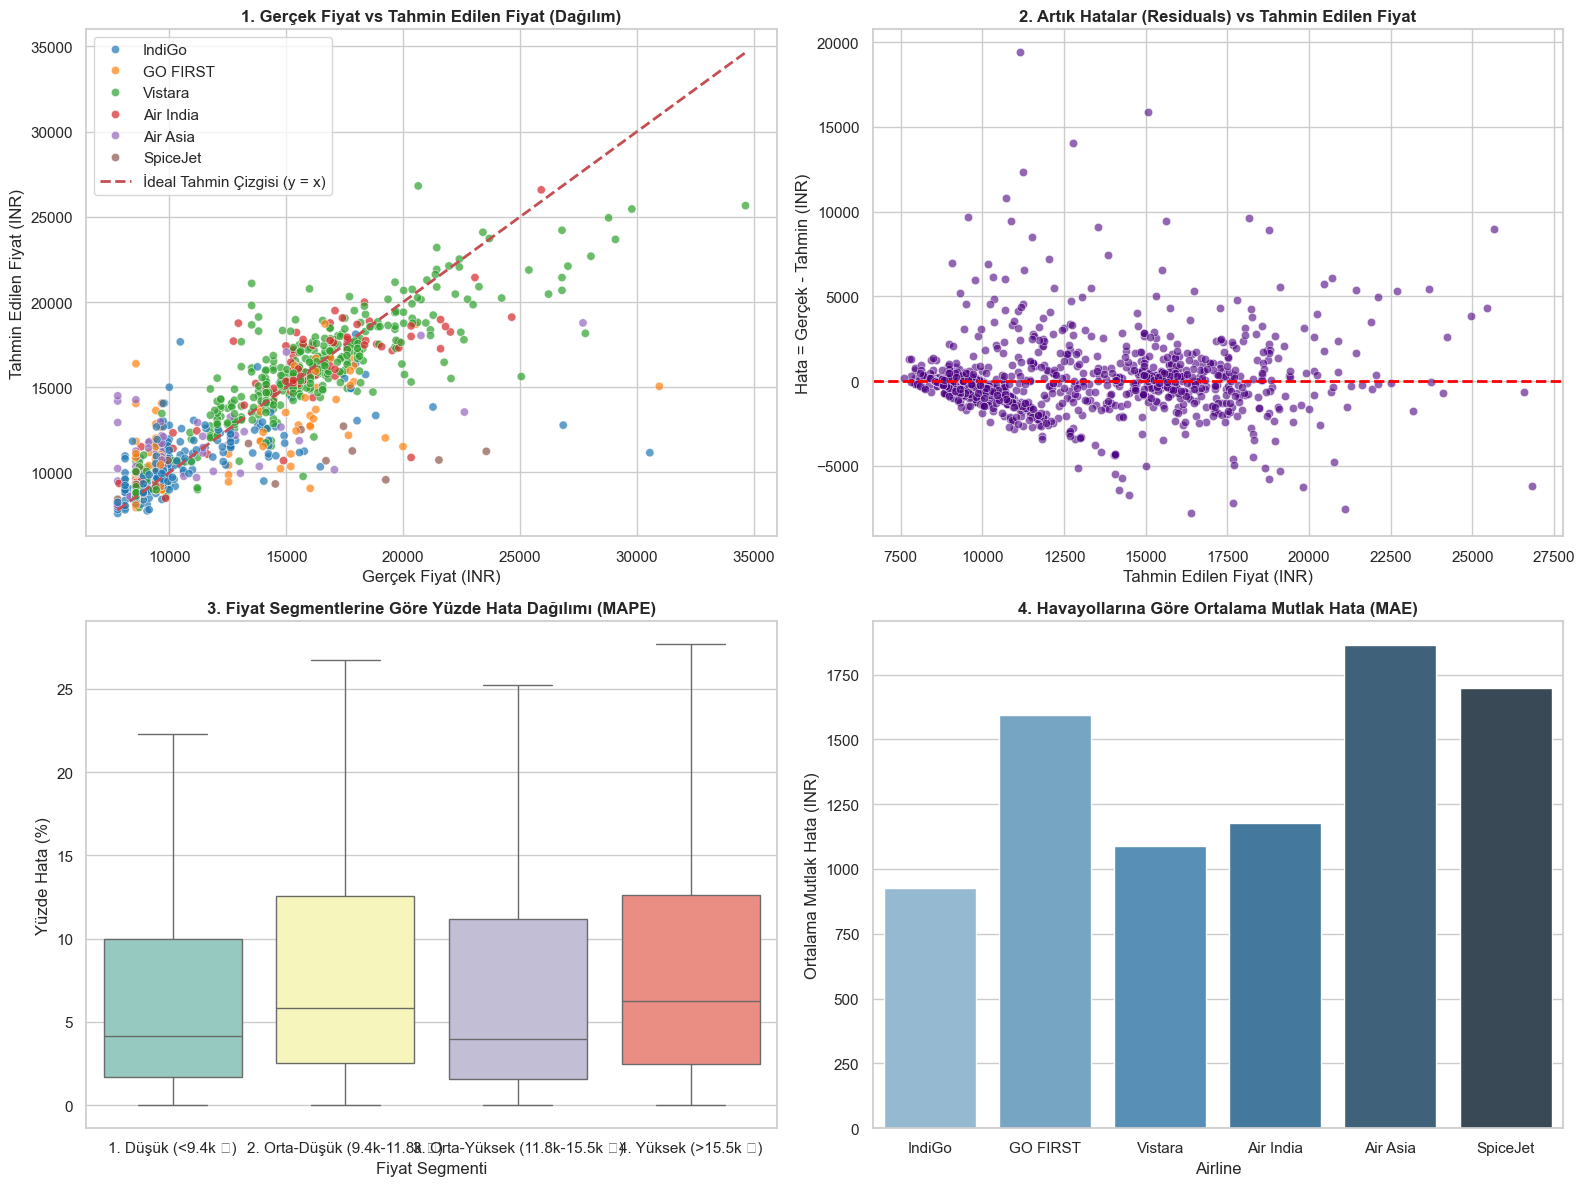

In [11]:
# Görselleştirme: Hata Desenleri ve Segment Analizi
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Actual vs Predicted Scatter
sns.scatterplot(data=test_eval, x='Price_Actual', y='Price_Pred', hue='Airline', alpha=0.7, ax=axes[0, 0], palette='tab10')
axes[0, 0].plot([test_eval['Price_Actual'].min(), test_eval['Price_Actual'].max()], [test_eval['Price_Actual'].min(), test_eval['Price_Actual'].max()], 'r--', lw=2, label='İdeal Tahmin Çizgisi (y = x)')
axes[0, 0].set_title('1. Gerçek Fiyat vs Tahmin Edilen Fiyat (Dağılım)', fontweight='bold')
axes[0, 0].set_xlabel('Gerçek Fiyat (INR)')
axes[0, 0].set_ylabel('Tahmin Edilen Fiyat (INR)')
axes[0, 0].legend()

# Chart 2: Residuals vs Predicted (Heteroscedasticity Check)
sns.scatterplot(data=test_eval, x='Price_Pred', y='Error', alpha=0.6, color='indigo', ax=axes[0, 1])
axes[0, 1].axhline(0, color='red', linestyle='--', lw=2)
axes[0, 1].set_title('2. Artık Hatalar (Residuals) vs Tahmin Edilen Fiyat', fontweight='bold')
axes[0, 1].set_xlabel('Tahmin Edilen Fiyat (INR)')
axes[0, 1].set_ylabel('Hata = Gerçek - Tahmin (INR)')

# Chart 3: Price Segment vs Absolute Percentage Error (MAPE)
sns.boxplot(data=test_eval, x='Price_Segment', y='Percentage_Error', palette='Set3', ax=axes[1, 0], showfliers=False)
axes[1, 0].set_title('3. Fiyat Segmentlerine Göre Yüzde Hata Dağılımı (MAPE)', fontweight='bold')
axes[1, 0].set_xlabel('Fiyat Segmenti')
axes[1, 0].set_ylabel('Yüzde Hata (%)')

# Chart 4: Error Distribution by Airline
sns.barplot(data=test_eval, x='Airline', y='Abs_Error', palette='Blues_d', ax=axes[1, 1], errorbar=None)
axes[1, 1].set_title('4. Havayollarına Göre Ortalama Mutlak Hata (MAE)', fontweight='bold')
axes[1, 1].set_ylabel('Ortalama Mutlak Hata (INR)')

plt.tight_layout()
plt.show()


In [12]:
print("=== 3. EN ÇOK TAHMİN BÖLÜNEN UÇUŞLAR (UNDERESTIMATION - Gerçek Fiyat >> Tahmin) ===")
print("Model bütçe uçuşu beklerken bilet fiyatının ani talep artışıyla tavan yaptığı durumlar:")
display(test_eval.sort_values(by='Error', ascending=False)[['Airline', 'Route', 'Lead_Time_Days', 'Duration_mins', 'Stops_Num', 'Price_Actual', 'Price_Pred', 'Error']].head(5))

print("\n=== 4. EN YÜKSEK TAHMİN EDİLEN UÇUŞLAR (OVERESTIMATION - Tahmin >> Gerçek Fiyat) ===")
print("Model yüksek fiyat beklerken biletin indirimli satıldığı durumlar:")
display(test_eval.sort_values(by='Error', ascending=True)[['Airline', 'Route', 'Lead_Time_Days', 'Duration_mins', 'Stops_Num', 'Price_Actual', 'Price_Pred', 'Error']].head(5))


=== 3. EN ÇOK TAHMİN BÖLÜNEN UÇUŞLAR (UNDERESTIMATION - Gerçek Fiyat >> Tahmin) ===
Model bütçe uçuşu beklerken bilet fiyatının ani talep artışıyla tavan yaptığı durumlar:


,Airline,Route,Lead_Time_Days,Duration_mins,Stops_Num,Price_Actual,Price_Pred,Error
4935,IndiGo,Kolkata -> Bangalore,1,630,1,30552,11156.896594,19395.103406
447,GO FIRST,Delhi -> Bangalore,3,265,1,30957,15054.243652,15902.756348
5656,IndiGo,Bangalore -> Kolkata,2,370,1,26847,12775.764958,14071.235042
308,SpiceJet,Delhi -> Bangalore,2,500,1,23558,11237.372360,12320.627640
445,SpiceJet,Delhi -> Bangalore,3,445,1,21529,10729.181689,10799.818311



=== 4. EN YÜKSEK TAHMİN EDİLEN UÇUŞLAR (OVERESTIMATION - Tahmin >> Gerçek Fiyat) ===
Model yüksek fiyat beklerken biletin indirimli satıldığı durumlar:


,Airline,Route,Lead_Time_Days,Duration_mins,Stops_Num,Price_Actual,Price_Pred,Error
4172,GO FIRST,Mumbai -> Delhi,2,620,2,8568,16379.761292,-7811.761292
4901,Vistara,Kolkata -> Bangalore,1,795,1,13519,21094.529744,-7575.529744
2722,IndiGo,Goa -> Delhi,2,340,1,10466,17664.381798,-7198.381798
5872,Air Asia,Bangalore -> Kolkata,5,675,1,7789,14498.081171,-6709.081171
5566,Air Asia,Bangalore -> Kolkata,2,1010,1,7789,14192.612363,-6403.612363


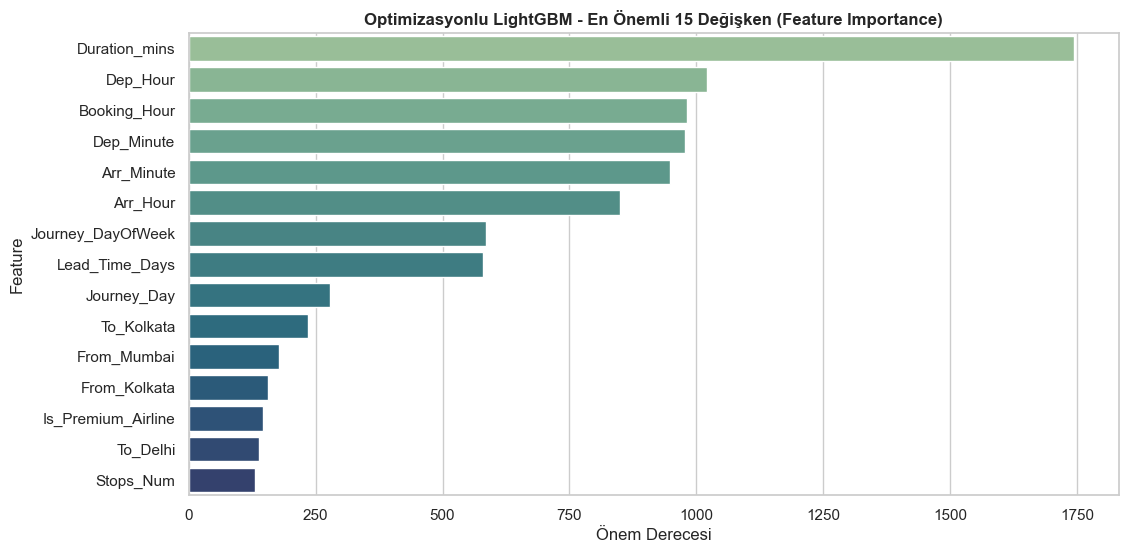

In [13]:
# Optimizasyonlu LightGBM Değişken Önem Dereceleri (Feature Importance)
ohe = preprocessor.named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + cat_feature_names

importances = best_lgb_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='crest')
plt.title('Optimizasyonlu LightGBM - En Önemli 15 Değişken (Feature Importance)', fontweight='bold')
plt.xlabel('Önem Derecesi')
plt.show()


## 9. 🎯 Sonuç ve Hata Analizi Özeti

### 🔍 Hatalar Rastgele mi Yoksa Sistematik mi?
Yapılan detaylı artık ve hata analizi sonucunda **hataların tam olarak rastgele (pure random noise) olmadığı, belirgin bir SİSTEMATİK DESEN çıkardığı** tespit edilmiştir:

1. **Düşük Fiyatlı Biletler (< 9.400 ₹):** Model bilet fiyatlarını ortalamada **~588 ₹ daha yüksek (Overestimation)** tahmin etmektedir. Model uçuşların belirli bir taban maliyetin altına inmeyeceğini varsaymaktadır.
2. **Orta Segment Biletler (11.800 - 15.500 ₹):** Model **neredeyse mükemmel** tahmin yapmaktadır (Medyan Hata: sadece **-15.4 ₹**!).
3. **Yüksek / Lüks Fiyatlı Biletler (> 15.500 ₹):** Model bilet fiyatlarını ortalamada **~1.398 ₹ daha düşük (Underestimation)** tahmin etmektedir. Bunun nedeni, son dakika rezervasyonlarında veya pik talep dönemlerinde bütçe havayollarının dahi 30.000+ ₹ seviyesine çıkan ekstrem bilet fiyatlarıdır.

---

### 📊 Model Performans Özeti:
* **En Başarılı Model:** **LightGBM (Tuned)**
* **$R^2$ Skoru:** **0.7566** (%75.7 açıklanan varyans)
* **Medyan Mutlak Yüzde Hata (MdAPE):** **%5.4** *(Test kümesindeki uçuşların yarısında tahmin hatası %5.4'ün altındadır!)*
* **Lineer Regresyon (Baseline) Karşılaştırması:** Lineer regresyon $R^2 = 0.4284$ kalırken, hiperparametre optimizasyonlu LightGBM hata oranını yarı yarıya düşürmüştür.
